# DC1d modelling and inversion
We want to use direct-current (DC) modelling for 1D layered Earth models.
This is readily implemented in the pyGIMLi (Python Geophysical Modelling and Inversion module).
We make use of the `PyCall` library to call the codes from Julia.

In [1]:
using PyCall
using PyPlot

In [2]:
pg=pyimport("pygimli")

PyObject <module 'pygimli' from 'c:\\src\\gimli\\gimli\\pygimli\\__init__.py'>

In [3]:
pos=pg.Pos([1, 1, 0])
mesh=pg.createGrid(5,5)
print(mesh)

PyObject Mesh: Nodes: 25 Cells: 16 Boundaries: 40

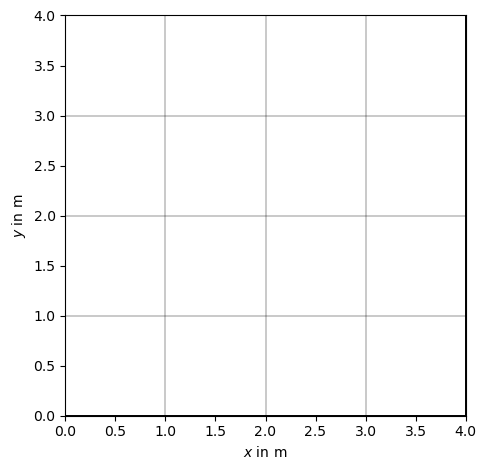

In [5]:
ax, cb = mesh.show()
ax.figure

In [6]:
# We define a AB/2 vector going from 1 to 1000m
ab2 = 10 .^ (0:0.1:3);
# ab2 = np.logspace(0, 3, 31)

31-element Vector{Float64}:
    1.0
    1.2589254117941673
    1.5848931924611136
    1.9952623149688795
    2.51188643150958
    3.1622776601683795
    3.9810717055349722
    5.011872336272722
    6.309573444801933
    7.943282347242816
    ⋮
  158.48931924611142
  199.52623149688787
  251.18864315095797
  316.22776601683796
  398.1071705534973
  501.18723362727246
  630.957344480193
  794.3282347242813
 1000.0

In [25]:
# Now we define a 1D DC forward operator, for MN/2 we use AB/2 / 3
number_of_layers = 3
f = pg.physics.ves.VESModelling(ab2, ab2/3, nLayers=number_of_layers)

PyObject <pygimli.physics.ves.vesModelling.VESModelling object at 0x000001531A889CB0>

In [39]:
rhoa = f([5, 5, 100, 20, 100]).array();  # two thicknesses, three resistivities
error = 0.03
rhoa = rhoa .* (randn(length(rhoa)) .* error .+ 1)

31-element Vector{Float64}:
 100.17015325298748
 101.08270550766744
 104.41273650444167
  98.20235342891344
  97.27740600814236
  97.3342156541694
  93.57471282790235
  92.3924980919626
  81.72851221370848
  75.76872108097437
   ⋮
  87.63407015109426
  90.02704244183914
  96.28172863488005
  89.25291671220813
  98.97372549724082
 102.9992911826715
  99.48124390899606
 104.15116893766252
  96.30568243909879

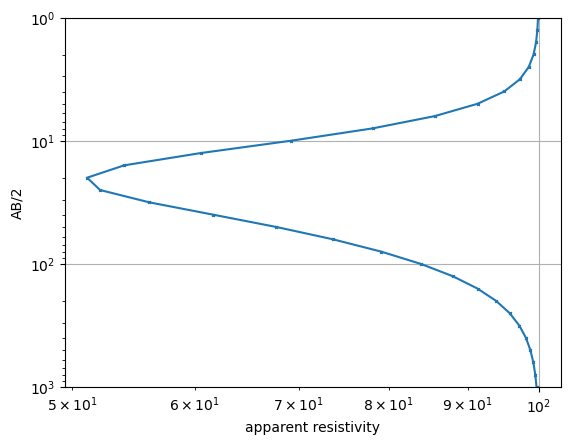

In [27]:
figure()
loglog(rhoa, ab2, "x-")
ylim(ab2[end], ab2[1])
xlabel("apparent resistivity")
ylabel("AB/2");
grid()
gcf()

Whereas `DC1dModelling` gets thickness and resistivity values, there is a variant `DC1dRhoModelling` for only resistivity using a predefined thickness vector. This is made for smoothness-constrained inversion.

In [29]:
thk = ones(30)
fRho = pg.core.DC1dRhoModelling(thk, ab2, ab2/3);

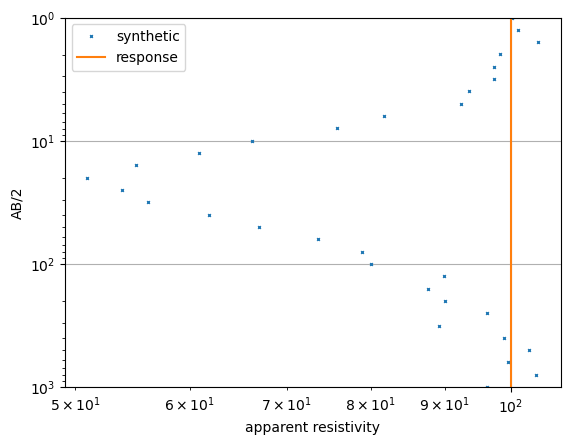

In [46]:
rho = ones(length(thk)+1) * 100
# rho[6:10] .= 20
response = fRho(rho).array()
figure()
loglog(rhoa, ab2, "x", label="synthetic")
loglog(response, ab2, label="response")
grid()
legend()
ylim(ab2[end], ab2[1])
xlabel("apparent resistivity")
ylabel("AB/2");
gcf()

Install the PyCall by calling
```
using Pkg
Pkg.add("PyCall")
```
Make sure pyGIMLi is installed by calling on the Anaconda command line
```
conda install -c gimli -c conda-forge pygimli=1.5.4
```

## Task
1. Write a Julia function using the variable-layer forward operator 
1. Write a Julia function using the fixed-layer forward operator 
1. generate a synthetic three-layer model and compute its forward response
1. write a function for computing the Jacobian matrix using the perturbation method
$$ \frac{\partial {\bf f}({\bf m})}{\partial m_j} \approx
\frac{{\bf f}({\bf m} + \delta_j\Delta m )-{\bf f}({\bf m})}{\Delta m} $$
1. Start with a homogeneous resistivity model.
1. compute its Jacobian matrix and display it using matshow

## Task 2:
Generate a three-layer model of which the first and last resistivity model and the thickness of the first layer is assumed constant. Vary the second layer resistivity and thickness over a certain range and plot the resulting objective function $\|d-f(m)\|^2$  as a matrix.

$$ S_{:,j}=\frac{\partial {\bf f}({\bf m})}{\partial m_j} \approx
\frac{{\bf f}({\bf m} + \delta_j\Delta m )-{\bf f}({\bf m})}{\Delta m} $$

$$ \Delta {\bf m} = (S^T S)^{-1} (S^T \Delta d) \quad\text{with}\quad \Delta d=d-f(m) $$

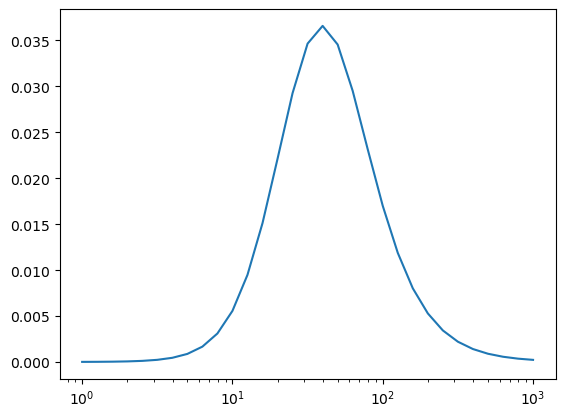

In [ ]:
# function sens(??)
S = ones(??, ??)
for i = 1:length()
    rho1 = rho * 1.0 # make a copy
    rho1[i] = rho[i] + 1 # local change at one position
    S[??] = (fRho(rho1) - fRho(rho)) / 1 # how does one parameter change affect model response
end
# return S
# end
figure()
PLOTTE(S)
gcf()

In [45]:
rho

31-element Vector{Float64}:
 100.0
 100.0
 100.0
 100.0
 100.0
 100.0
 100.0
 100.0
 100.0
 101.0
   ⋮
 100.0
 100.0
 100.0
 100.0
 100.0
 100.0
 100.0
 100.0
 100.0